# Exploratory Data Analysis - Diabetes Dataset
## Pima Indians Diabetes Database

This notebook preserves the original EDA from the source notebook, including all specific plots, markdown observations, and analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/diabetes.csv")

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
df["Outcome"].value_counts() / len(df) * 100  # data imbalanced

Outcome
0    65.104167
1    34.895833
Name: count, dtype: float64

**Observation:** The dataset is imbalanced — ~65% non-diabetic (Outcome=0) and ~35% diabetic (Outcome=1).

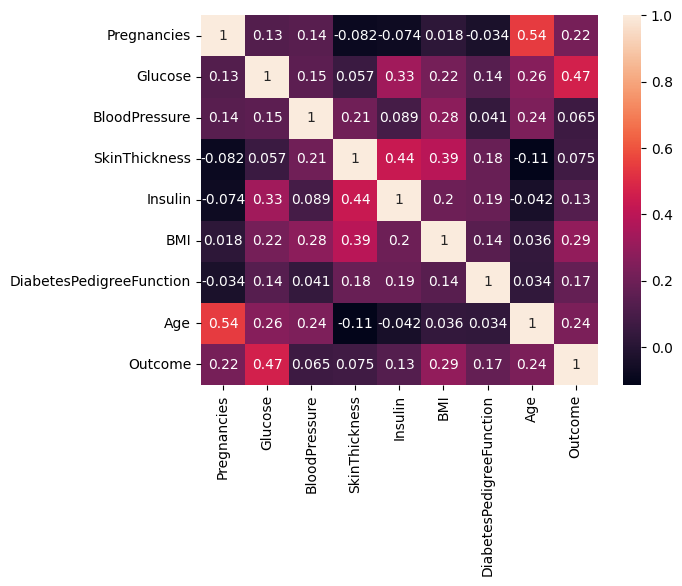

In [8]:
sns.heatmap(df.corr(), annot=True)
plt.show()

In [9]:
df["Age"].min(), df["Age"].max()

(np.int64(21), np.int64(81))

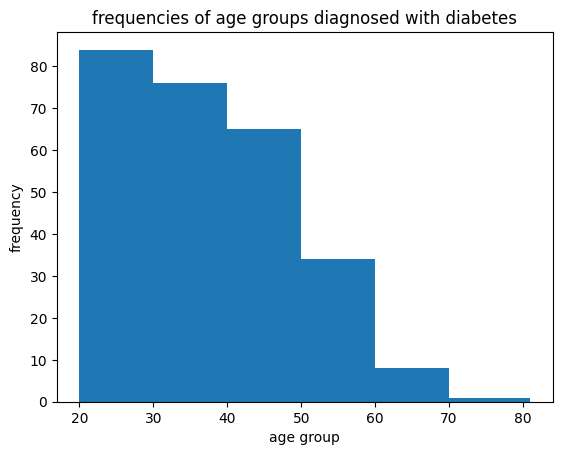

In [10]:
plt.hist(df["Age"].where(df["Outcome"] == 1), bins=[20, 30, 40, 50, 60, 70, 81])
plt.title("frequencies of age groups diagnosed with diabetes")
plt.xlabel("age group")
plt.ylabel("frequency")
plt.show()

1. Majority people who are diagnosed with diabetes are from age group 20-50 which is approximately 94.5%.
2. approximately 5.46% people who are diagnosed with diabetes are from age group 50-80

In [11]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

1. Outcome correlation with other features that we got from the heatmap

Glucose > BMI > Age > Pregnancies > DiabetesPedigreeFunction > Insulin

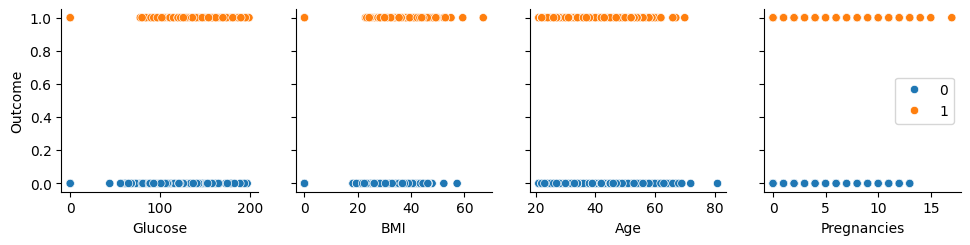

In [12]:
variables = ['Glucose', 'BMI', "Age", "Pregnancies"]
g = sns.PairGrid(df, hue="Outcome", x_vars=variables, y_vars=['Outcome'])
g.map_diag(sns.histplot)
g.map_offdiag(sns.scatterplot)
plt.legend()
plt.show()

In [13]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

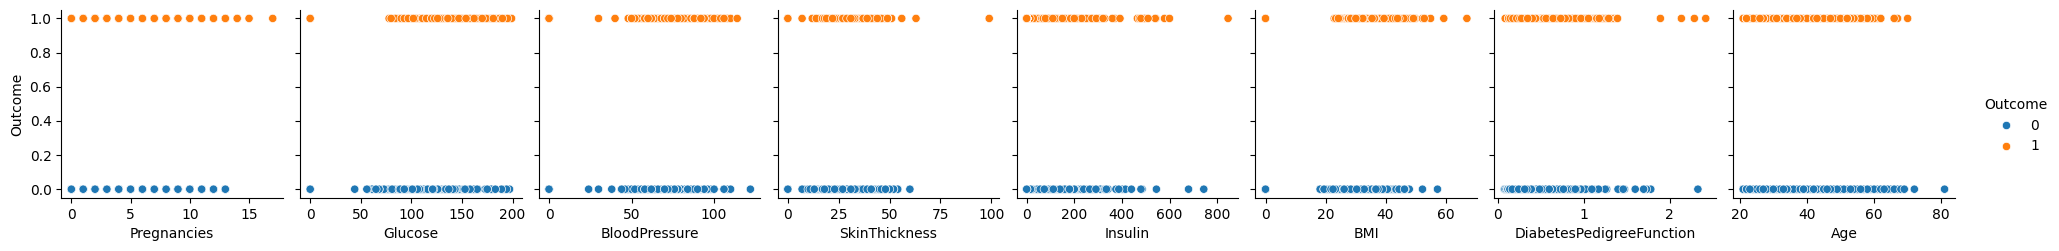

In [15]:
sns.pairplot(
    df,
    x_vars=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
    y_vars=["Outcome"],
    hue="Outcome"
)

## Outlier Detection

In [16]:
x_vars = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']

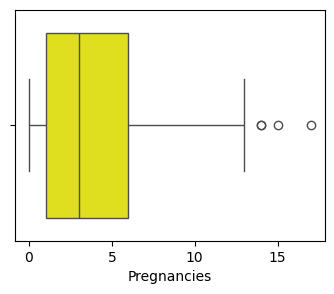

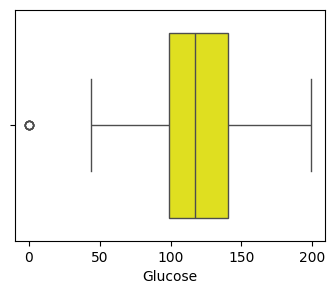

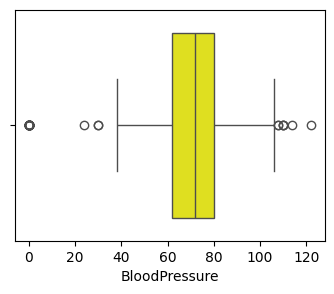

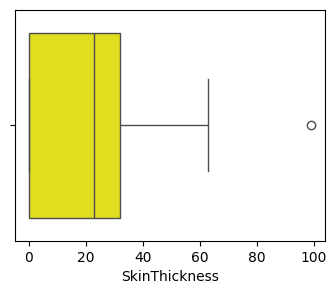

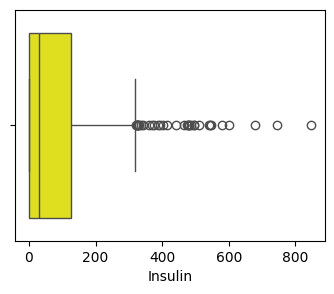

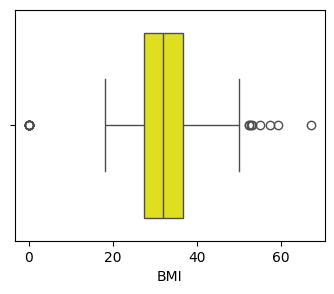

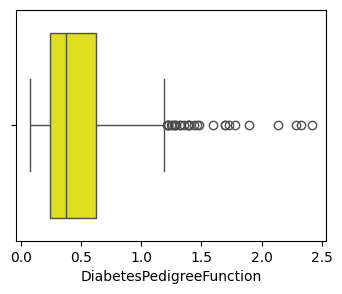

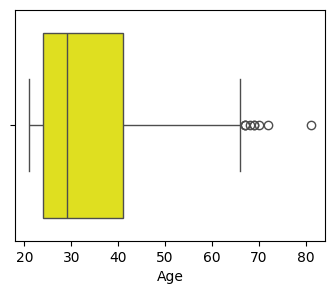

In [17]:
for i in x_vars:
    plt.figure(figsize=(4, 3))
    sns.boxplot(x=df[i], color="yellow")
    plt.show()

Insulin and DiabetesPedigreeFunction has more number of outliers

In [18]:
# Removing the outliers
def remove_outliers(df, features):
    """
    Removes outliers from the specified features in the DataFrame.

    Parameters:
    - df: The original DataFrame
    - features: List of column names to check for outliers

    Returns:
    - DataFrame with outliers removed from the specified features
    """
    cleaned_df = df.copy()
    for feature in features:
        Q1 = cleaned_df[feature].quantile(0.25)
        Q3 = cleaned_df[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        cleaned_df[feature] = np.where(
            (cleaned_df[feature] < lower_bound) | (cleaned_df[feature] > upper_bound),
            np.nan,
            cleaned_df[feature]
        )
    return cleaned_df

In [19]:
df2 = remove_outliers(df, features=["Insulin", "DiabetesPedigreeFunction"])

In [20]:
df2.shape

(768, 9)

In [21]:
df2.isnull().sum()

Pregnancies                  0
Glucose                      0
BloodPressure                0
SkinThickness                0
Insulin                     34
BMI                          0
DiabetesPedigreeFunction    29
Age                          0
Outcome                      0
dtype: int64

In [22]:
100 - (len(df2.dropna()) / len(df2) * 100)  # % of data loss when outliers are removed

7.942708333333343

In [23]:
df2 = df2.dropna()

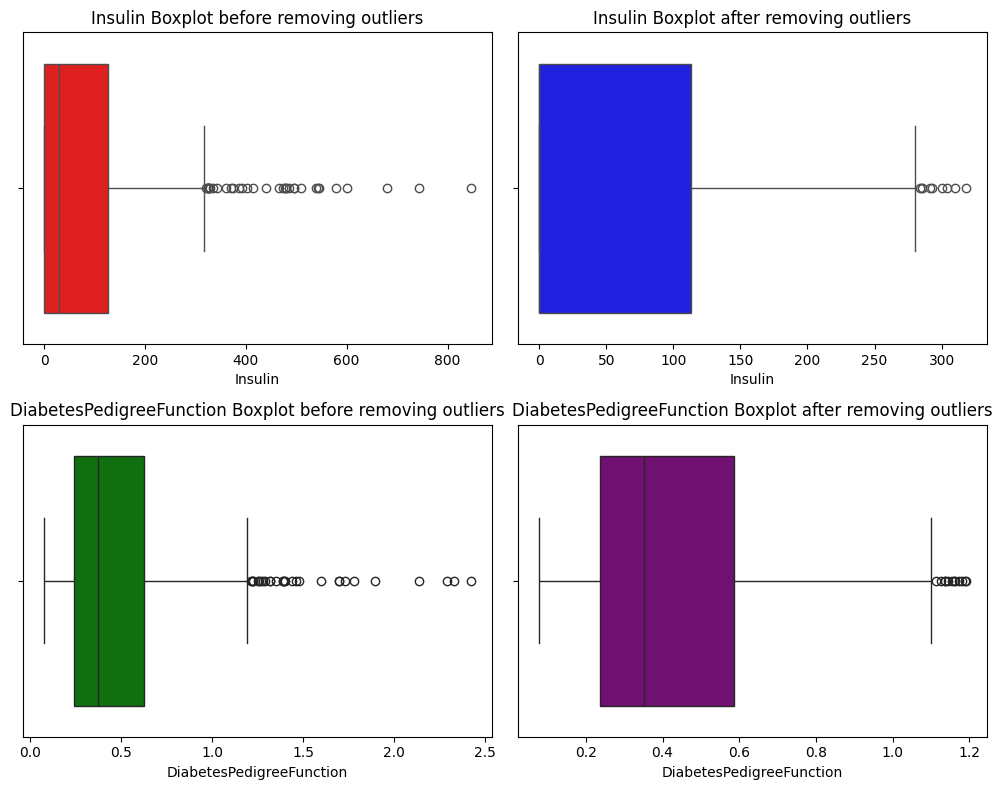

In [24]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
sns.boxplot(x=df["Insulin"], ax=axs[0, 0], color="red")
axs[0, 0].set_title("Insulin Boxplot before removing outliers")

sns.boxplot(x=df2["Insulin"], ax=axs[0, 1], color="blue")
axs[0, 1].set_title("Insulin Boxplot after removing outliers")

sns.boxplot(x=df["DiabetesPedigreeFunction"], ax=axs[1, 0], color="green")
axs[1, 0].set_title("DiabetesPedigreeFunction Boxplot before removing outliers")

sns.boxplot(x=df2["DiabetesPedigreeFunction"], ax=axs[1, 1], color="purple")
axs[1, 1].set_title("DiabetesPedigreeFunction Boxplot after removing outliers")
plt.tight_layout()
plt.show()

## Summary of EDA Findings

1. **Dataset**: 768 samples, 8 features + 1 target (Outcome)
2. **Class Imbalance**: ~65% non-diabetic, ~35% diabetic — requires balancing (SMOTE)
3. **Top Correlated Features** (with Outcome): Glucose > BMI > Age > Pregnancies > DiabetesPedigreeFunction > Insulin
4. **Age Distribution**: ~94.5% of diabetic patients are in the 20-50 age group
5. **Missing/Zero Values**: Some features (Glucose, BloodPressure, BMI) have biologically implausible zero values
6. **Outliers**: Insulin and DiabetesPedigreeFunction have significant outliers — addressed via IQR method (~8% data loss)
7. **No Duplicates**: No duplicate rows found